# Perovskite water splitting
computational screening of around 19,000 oxides, oxynitrides, oxyfluorides, and oxyfluoronitirides in the cubic perovskite structure with photoelectrochemical applications in mind.



*   Castelli, I. E., Landis, D. D., Thygesen, K. S., Dahl, S., Chorkendorff, I., Jaramillo, T. F., and Jacobsen, K. W. Energy Environ. Sci. 5, 9034.
*   Castelli, I. E., Olsen, T., Datta, S., Landis, D. D., Dahl, S., Thygesen, K. S., and Jacobsen, K. W. Energy Environ. Sci. 5, 5814.

*   Castelli, I. E., Thygesen, K. S., and Jacobsen, K. W. Topics in Catalysis 57, 265.



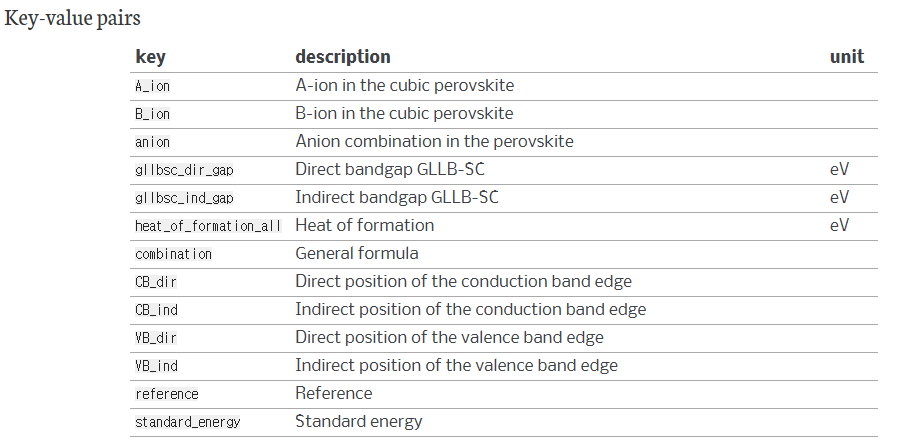

In [12]:
!pip install -q pymatgen matminer
!pip install ase -q

In [13]:
import sys, warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matminer, pymatgen, sklearn
from pymatgen.core import Composition, Structure
from pathlib import Path

In [25]:
DIR = Path("../../content/sample_data/PVSK")
print("PVSK DIR : ", DIR)

PVSK DIR :  ../../content/sample_data/PVSK


In [26]:
from __future__ import print_function
import ase.db
from ase.phasediagram import PhaseDiagram

con = ase.db.connect('../../content/sample_data/PVSK/cubic_perovskites.db')

references = [(row.formula, row.energy)
              for row in con.select('reference')]

with open('abo3.csv', 'w') as fd:
    print('# id, formula, heat of formation [eV/atom]', file=fd)
    for row in con.select(combination='ABO3'):
        pd = PhaseDiagram(references, filter=row.formula, verbose=False)
        energy = pd.decompose(row.formula)[0]
        heat = (row.energy - energy) / row.natoms
        if (heat < 0.21 and
            (3.1 > row.gllbsc_ind_gap > 1.4 or
             3.1 > row.gllbsc_dir_gap > 1.4) and
            (row.VB_ind - 4.5 > 1.23 and row.CB_ind - 4.5 < 0 or
             row.VB_dir - 4.5 > 1.23 and row.CB_dir - 4.5 < 0)):
            formula = row.A_ion + row.B_ion + row.anion
            print('{0}, {1}, {2:.3f}'.format(row.id, formula, heat), file=fd)

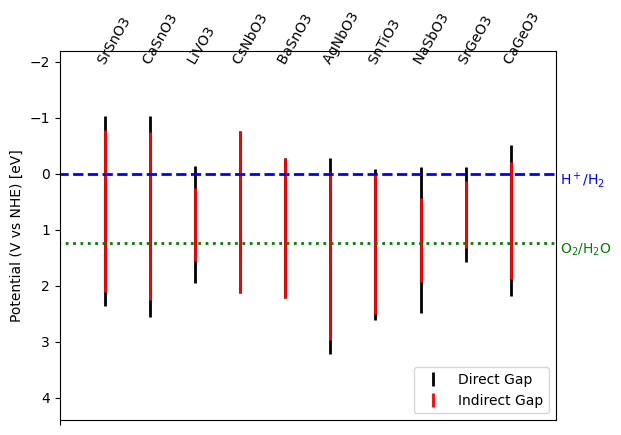

In [27]:
con = ase.db.connect('../../content/sample_data/PVSK/cubic_perovskites.db')

rows = []
for i, line in enumerate(open('abo3.csv')):
    if line[0] == '#':
        continue
    id, formula = line.split(',')[:2]
    id = int(id)
    row = con.get(id)
    rows.append(row)
    plt.text(i - 1.25, -1.9, formula, rotation=60)

N = len(rows)
# assert N == 10 # Removed assertion to fix the AssertionError
x = range(N)
y = [(row.VB_ind + row.CB_ind) / 2 - 4.5 for row in rows]
dyd = [row.gllbsc_dir_gap / 2 for row in rows]
dyi = [row.gllbsc_ind_gap / 2 for row in rows]
plt.errorbar(x, y, dyd, color='k', lw=0, mew=2, elinewidth=2,
             label='Direct Gap')
plt.errorbar(x, y, dyi, color='r', lw=0, mew=2, elinewidth=2,
             label='Indirect Gap')
plt.xlim(-1, N)
plt.ylim(4.4, -2.2)
plt.axhline(y=0, xmin=-1, xmax=N, lw=2, color='b', ls='dashed')
plt.axhline(y=1.23, xmin=-1, xmax=N, lw=2, color='g', ls='dotted')
plt.text(N + 0.1, 0.2, 'H$^+$/H$_2$', color='b')
plt.text(N + 0.1, 1.43, 'O$_2$/H$_2$O', color='g')
plt.ylabel('Potential (V vs NHE) [eV]')
plt.xticks([-1], '')
plt.legend(loc=4)
plt.savefig('abo3.svg')

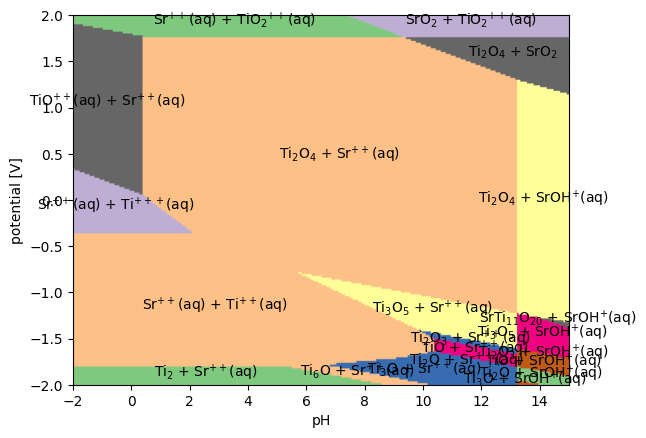

In [32]:
# creates: SrTiO3_pourbaix.png
import numpy as np
import matplotlib.pyplot as plt
import ase.db
from ase.phasediagram import Pourbaix, solvated

con = ase.db.connect('../../content/sample_data/PVSK/cubic_perovskites.db')

refs = []
for row in con.select('reference'):
    refs.append((row.formula, row.standard_energy))

# Add other solid/dissolved phases not included before:
refs += [('Ti6O', -5.443), ('Ti2O3', -13.907), ('Ti2O', -5.164),
         ('TiO', -4.838), ('SrO2', -5.356), ('Ti3O', -5.346),
         ('Ti3O5', -22.917), ('Sr4Ti3O10', -50.756), ('SrTi11O20', -93.313)]

# Extract the dissolved phases:
refs += solvated('SrTi')

pb = Pourbaix(refs, formula='SrTiO3')
U = np.linspace(-2, 2, 200)
pH = np.linspace(-2, 15, 300)
d, names, text = pb.diagram(U, pH, plot=True, show=False)

plt.savefig('SrTiO3_pourbaix.png')

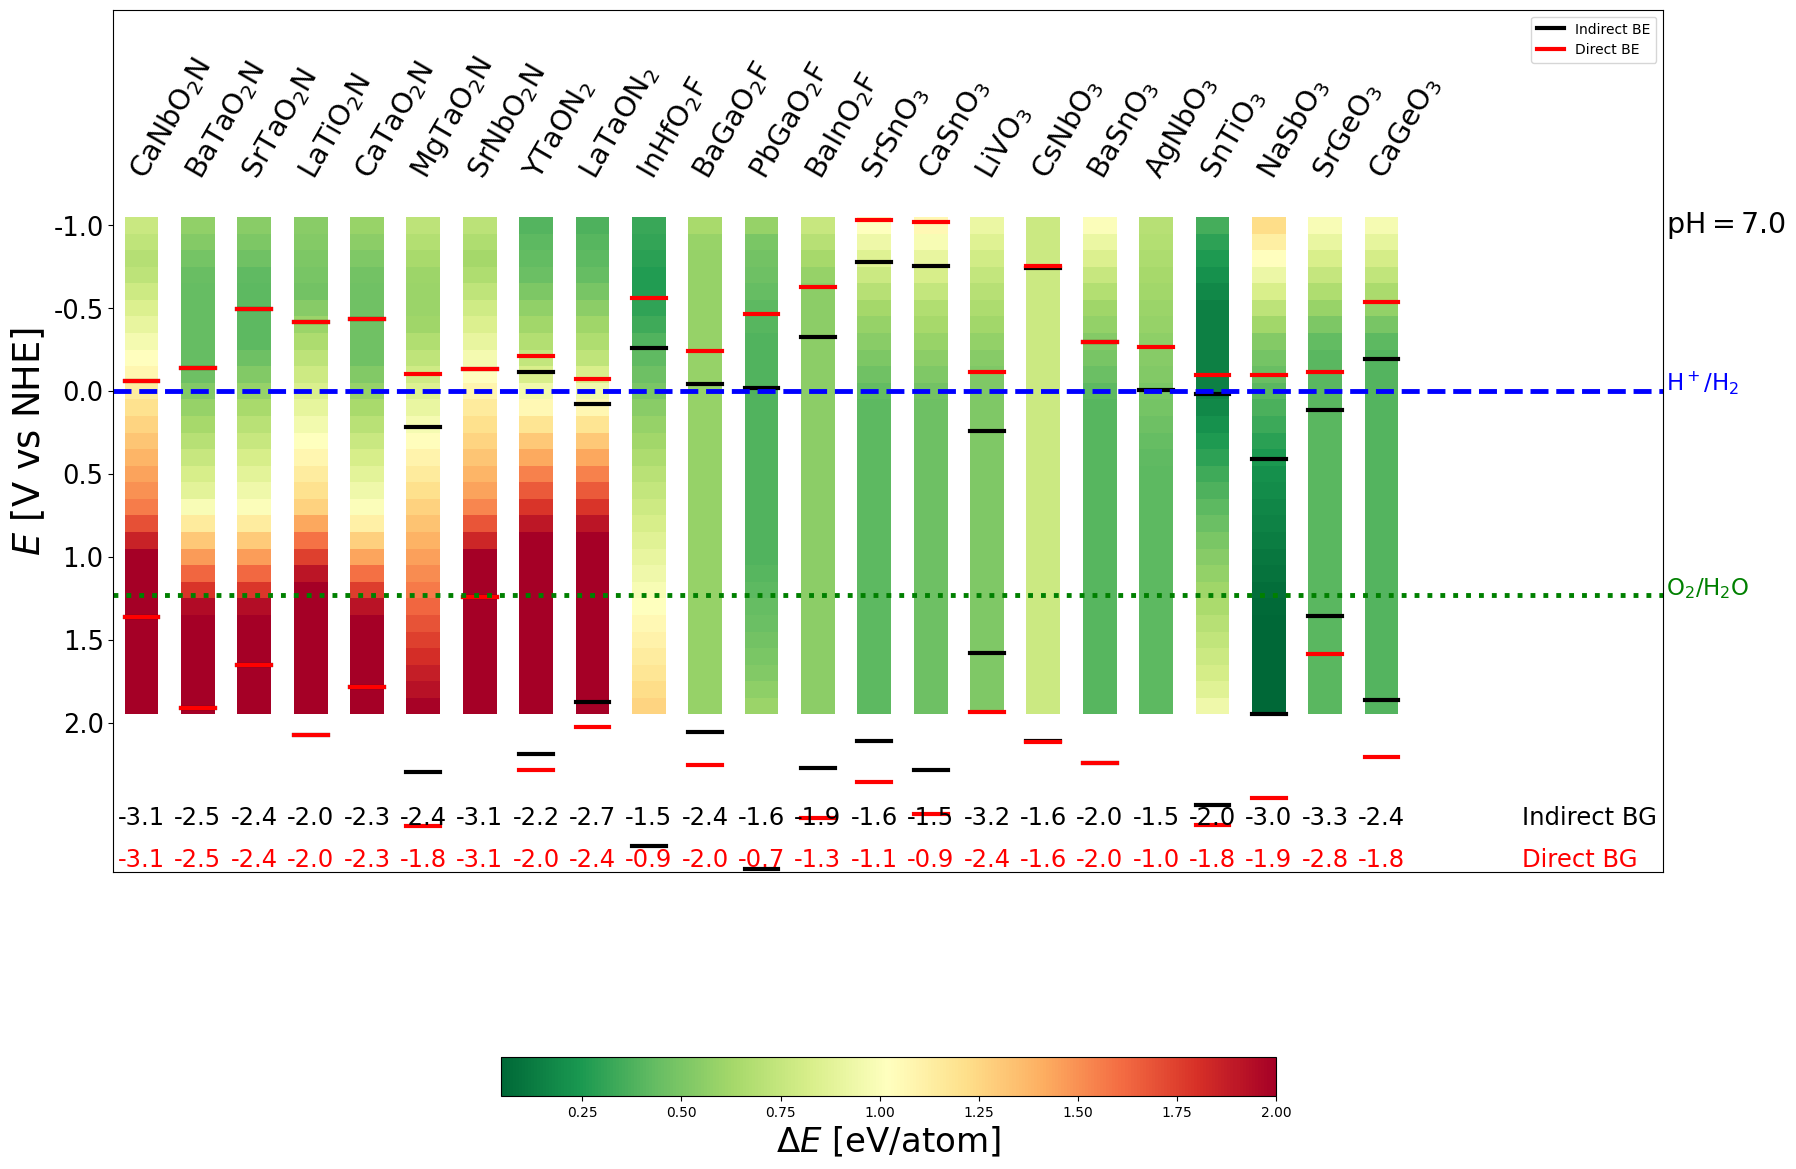

In [31]:
# creates: WS_pourbaix.png
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.collections import PatchCollection
import matplotlib.patches as patches
import ase.db
from ase.phasediagram import Pourbaix, solvated

con = ase.db.connect('../../content/sample_data/PVSK/cubic_perovskites.db')

pH = 7.
Us = np.arange(-1, 2, 0.1)
E0 = -4.5
lb = -0.5  # lower bound for the energy scale
ub = 2.0  # upper bound for the energy scale

info = []
xs = []
ys = []
heats = []

for row in con.select('heat_of_formation_all<=0.21'):
    if (row.gllbsc_ind_gap >= 1.4 and row.gllbsc_ind_gap <= 3.1 and
        row.CB_ind <= 0 - E0 and row.VB_ind >= 1.23 - E0) or \
       (row.gllbsc_dir_gap >= 1.4 and row.gllbsc_dir_gap <= 3.1 and
        row.CB_dir <= 0 - E0 and row.VB_dir >= 1.23 - E0):
        name = row.A_ion + row.B_ion + row.anion
        energy = row.standard_energy

        info.append([name, row.gllbsc_ind_gap + E0, row.gllbsc_dir_gap + E0,
                     row.VB_ind + E0, row.CB_ind + E0,
                     row.VB_dir + E0, row.CB_dir + E0])

        refs = []
        for row_ref in con.select('reference'):
            refs.append((row_ref.formula, row_ref.standard_energy))

        # Extract the dissolved phases:
        refs += solvated(row.A_ion + row.B_ion)

        for U in Us:
            pb = Pourbaix(refs, name)
            results, refs_energy = pb.decompose(U, pH, verbose=False)
            Ediff = (energy - refs_energy) / 5
            Ediff = min(Ediff, ub)
            Ediff = max(Ediff, lb)
            xs.append(len(info) - 1)
            ys.append(U)
            heats.append(Ediff)

fig = plt.figure(figsize=(20, 16))
ax = fig.add_subplot(111)

cx = 0.3
cy = 0.05
rects = []
for i in range(len(heats)):
    rect = patches.Rectangle((xs[i] - cx, ys[i] - cy), 2 * cx, 2 * cy)
    rects.append(rect)
p = PatchCollection(rects, edgecolors=None, linewidths=0, cmap=cm.RdYlGn_r)
p.set_array(np.array(heats))
ax.add_collection(p)

for i in range(len(info)):
    plt.plot([i - cx, i + cx], [info[i][3], info[i][3]], '-',
             color='k', linewidth=3)
    plt.plot([i - cx, i + cx], [info[i][4], info[i][4]], '-',
             color='k', linewidth=3)
    plt.plot([i - cx, i + cx], [info[i][5], info[i][5]], '-',
             color='r', linewidth=3)
    plt.plot([i - cx, i + cx], [info[i][6], info[i][6]], '-',
             color='r', linewidth=3)
    plt.text(i, 2.5, round(info[i][1], 1), color='k', fontsize=17.5,
             verticalalignment='top', horizontalalignment='center')
    plt.text(i, 2.75, round(info[i][2], 1), color='r', fontsize=17.5,
             verticalalignment='top', horizontalalignment='center')
plt.plot([cx, cx], [info[0][3], info[0][3]], '-', color='k', linewidth=3,
         label='Indirect BE')
plt.plot([cx, cx], [info[0][5], info[0][5]], '-', color='r', linewidth=3,
         label='Direct BE')
plt.text(len(info) + 1.5, 2.5, 'Indirect BG', color='k', fontsize=17.5,
         verticalalignment='top', horizontalalignment='left')
plt.text(len(info) + 1.5, 2.75, 'Direct BG', color='r', fontsize=17.5,
         verticalalignment='top', horizontalalignment='left')

for i in range(len(info)):
    formula = info[i][0]
    for j in range(10):
        if str(j) in formula:
            formula = formula.replace(str(j), "$_" + str(j) + "$")
    plt.text(i - cx, -1.25, formula, rotation=60, va='bottom', ha='left',
             fontsize=20.5, color='k')

xmax = len(info) + 4
plt.text(xmax + 0.05, -1, 'pH$=' + str(pH) + '$', color='black', fontsize=20.5,
         verticalalignment='center')
plt.axhline(1.23, xmin=0, xmax=xmax, color='g', ls='dotted', lw=3.5)
plt.text(xmax + 0.05, 1.23, 'O$_2$/H$_2$O', color='g', fontsize=16.5)
plt.axhline(0, xmin=0, xmax=xmax, color='b', ls='dashed', lw=3.5)
plt.text(xmax + 0.05, 0, 'H$^+$/H$_2$', color='b', fontsize=16.5)

cbar = plt.colorbar(p, orientation='horizontal', shrink=0.5)
cbar.set_label(r'$\Delta E$ [eV/atom]', fontsize=24.5)

plt.ylabel('$E$ [V vs NHE]', fontsize=26.5)
plt.yticks([-1, -0.5, 0, 0.5, 1, 1.5, 2],
           ['-1.0', '-0.5', '0.0', '0.5', '1.0', '1.5', '2.0'],
           fontsize=18.5)
plt.xticks([])
plt.legend()
plt.xlim(xmin=-0.5, xmax=xmax)
plt.ylim(ymin=-2.3, ymax=2.9)
plt.gca().invert_yaxis()

plt.savefig('WS_pourbaix.png')